A continuous-time stochastic process:
### Properties:
1. **Starts at 0**
$$W_0=0$$
2. **Independent increments**
	For times
$$ 0 <= t_0 < t_1 < ... <t_n $$
	increments
$$W_{t_1}-W_{t_0},...,W_{t_n}-W_{t_{n-1}}$$
	are independent random variables
$$W_t \sim N(0,t) $$
$$W_t - W_s \sim N(0,t-s)$$
3. **Increment Distribution depends only on the time difference**
$$W_t - W_s \sim W_{t-s}$$
	for $0 \le s<t$

4. **Normally distributed increments**
$$W_t-W_s\sim N(0,t-s)$$
5. **Continuous sample paths**
	With high probability,
$$\text{lim}_{s\to t}\space W_s(\omega)=W_t(\omega)$$
	This comes from the epsilon-delta definition of continuity. For any epsilon, we can construct a delta such that the function value within that delta falls within the epsilon range with very high probability. But it can never be guaranteed to fall in that boundary. 
### Simulation Perspective:
Understand the properties from a simulation perspective:
1. All simulations start at 0
2. The change in a given time interval should not depend on the value of the process at the start of the interval
3. Taking many simulations until t and tracking their simulated values at s and at t-s, the distribution of their values at t-s should equal the distribution of the difference between the value at t subtracted b the value at s per simulation.
4. We can simulate a single Brownian path by using the normal distribution over small intervals.
### Single Path Simulation

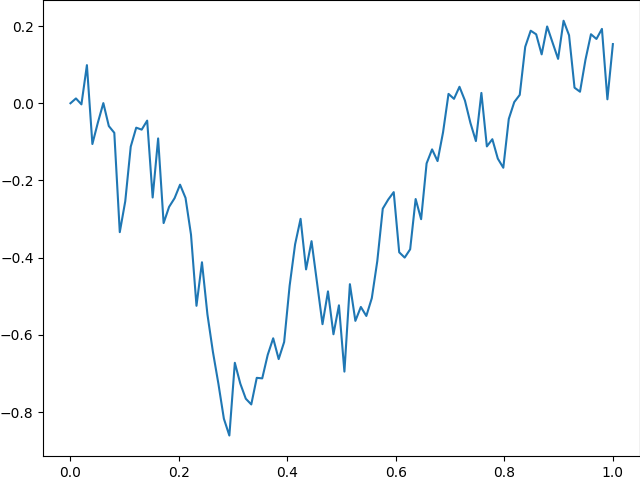

In [14]:
import numpy as np
import math
import matplotlib.pyplot as plt

rng = np.random.default_rng()
def generate_brownian_path(finish, steps):
	path = np.zeros(steps)
	time_step = finish / steps
	for i in range(1, steps):
		path[i] = (path[i-1] + 
		next_step(time_step))
	return path
	
def next_step(time_step):
	return math.sqrt(time_step)*rng.standard_normal()
	
#initialize parameters
finish = 1
steps = 100

#generate path
path = generate_brownian_path(finish, steps)
x_values = np.linspace(0, finish, steps)
plt.plot(x_values, path)
plt.show()

### Multi Path Simulation

W_t-W_s variance:0.29752254704115383
W_(t-s) variance:0.2847484664027312


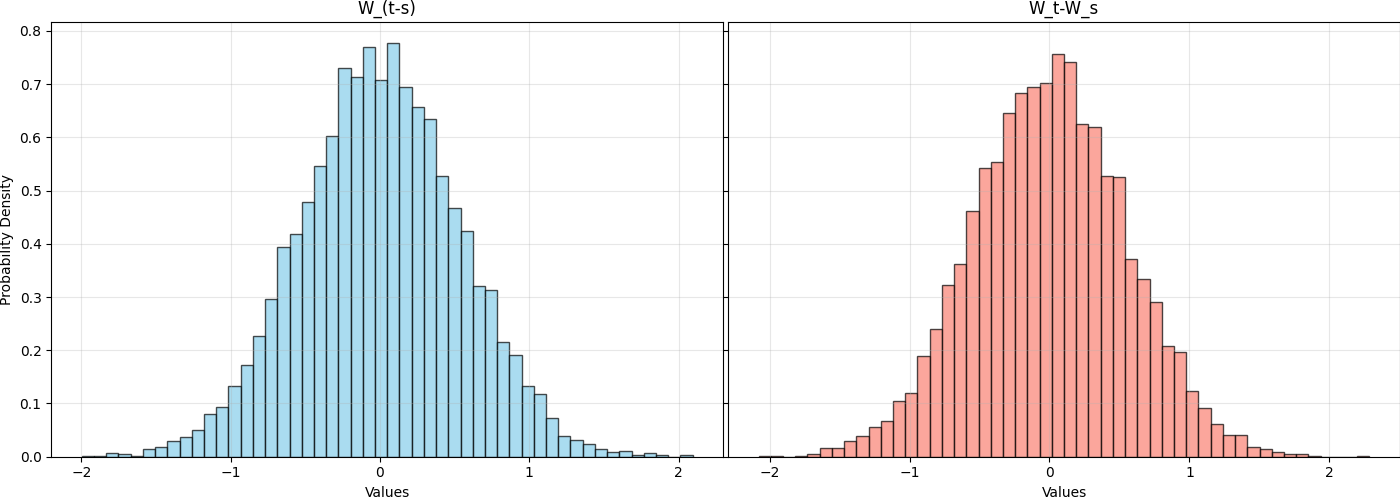

In [1]:
import numpy as np 
import warnings 
warnings.filterwarnings("ignore", category=UserWarning, message=".*Matplotlib is currently using agg.*")
import matplotlib.pyplot as pl

finish = 1
t = 70
s = 40 
r = t-s
steps = 100 
paths = 10000
time_step = finish / steps 
rng = np.random.default_rng()

intervals = rng.normal(0, np.sqrt(time_step), size=(paths, steps))
intervals[:, 0] = 0 # All paths start at 0
all_paths = np.cumsum(intervals, axis=1)

r_values = all_paths[:, t-s-1]
t_minus_s_values = all_paths[:, t-1]-all_paths[:,s-1]
# Create a figure with two subplots side-by-side 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot 1:
ax1.hist(r_values, bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.7) 
ax1.set_title(f'W_(t-s)') 
ax1.set_xlabel('Values') 
ax1.set_ylabel('Probability Density') 
ax1.grid(True, alpha=0.3) 
# Plot 2: 
ax2.hist(t_minus_s_values, bins=50, density=True, color='salmon', edgecolor='black', alpha=0.7) 
ax2.set_title(f'W_t-W_s') 
ax2.set_xlabel('Values') 
ax2.grid(True, alpha=0.3) 
plt.tight_layout() 
plt.show()
print(f'W_t-W_s variance:{np.var(t_minus_s_values)}')
print(f'W_(t-s) variance:{np.var(r_values)}')

### Important Consequences
- $E[W_t]=0$
- $\text{Var}[W_t] = t$
- $\text{Cov}(W_s, W_t) = \text{min}(s, t)$
	Proof: 
	Assume $s<t$,  $\text{Cov}(W_s, W_t) = E[W_sW_t]-E[W_s]E[W_t]$ by covariant properties [[Statistical Moments]]
	$E[X_t]=0$ so $\text{Cov}(W_s, W_t) = E[W_sW_t]$
	$W_t = W_s + W_{t-s}$  so we get $E[W_s(W_s + W_{t-s})]=E[W_s^2]+E[W_sW_{t-s}]$ 
	Disjoint intervals of Brownian process are independent, so $E[W_sW_{t-s}]=E[W_s]E[W_{t-s}]=0$
	$\text{Var}[W_s] = E[W_s^2]-E[W_s]^2$ according to [[Statistical Moments]]
	So, 	$\text{Cov}(W_s, W_t) = \text{Var}[W_s] + E[W_s]^2 = \text{Var}[W_s] = s$
	Since we assumed $s<t$, we can cover all scenarios with $\text{Cov}(W_s, W_t) = \text{min}(s,t)$
- 